In [1]:
import sys
sys.path.append('../src')
import torch
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.simulator import DDMSimulator, create_ddm_prior

In [12]:
simulator = DDMSimulator(
    initial_prob=0.8, 
    decay_rate=-0.1, 
    max_time=50.0, 
    noise_std=0,
    interval_mean=1.0, 
    interval_std=0.3, 
    interval_min=0.1, 
    interval_max=5.0)

params = torch.tensor([0.2, .1])
result = simulator(params)
print(f"Time: {result[0]:.2f}, Rewards: {int(result[1])}")

Time: 5.49, Rewards: 3


In [13]:
import matplotlib.pyplot as plt

def plot_ddm_trace(trace, figsize=(10, 6)):
    """Simple plot of DDM evidence and events"""
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=True)
    
    # Evidence over time
    ax1.plot(trace['times'], trace['evidence'], 'b-', linewidth=2)
    ax1.axhline(y=1, color='r', linestyle='--', label='Threshold')
    
    # Mark rewards
    for rt in trace['reward_times']:
        ax1.axvline(x=rt, color='g', alpha=0.6, linestyle=':')#, label='reward events')
    for rt in trace['no_reward_times']:
        ax1.axvline(x=rt, color='m', alpha=0.6, linestyle=':')#, label='no reward events')
    
    ax1.set_ylabel('Evidence')
    ax1.set_title('DDM Evidence Trajectory')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Events
    for rt in trace['reward_times']:
        ax2.scatter(rt, 1, c='green', s=50, label='Reward' if rt == trace['reward_times'][0] else "")
    ax2.scatter(0, 0, c='blue', s=50, label='Enter')
    ax2.scatter(trace['final_time'], 0, c='red', s=50, label='Leave')
    
    ax2.set_ylabel('Events')
    ax2.set_xlabel('Time')
    ax2.set_ylim(-0.5, 1.5)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

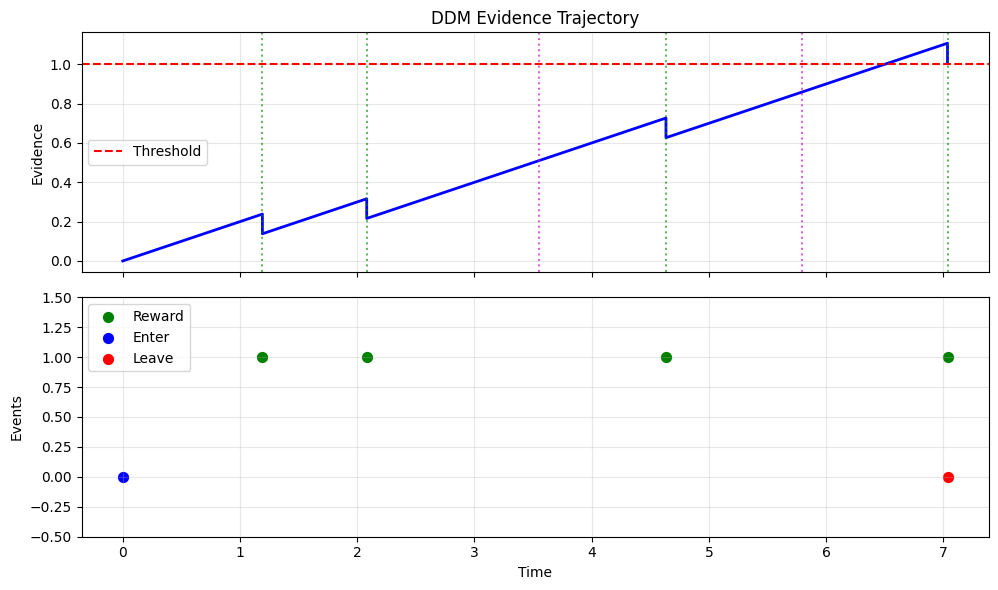

In [14]:
simulator = DDMSimulator(
    initial_prob=.8, #for the reward probability depletion fxn
    decay_rate=-0.1, 
    max_time=50.0, 
    noise_std=0.0,
    interval_mean=1.0, 
    interval_std=0.3, 
    interval_min=0.1, 
    interval_max=5.0)

    
# params = torch.tensor([1.2332, 0.7682]) # drift, reward_pulse
trace = simulator.simulate_single(params, save_trace=True)
fig = plot_ddm_trace(trace)
plt.show()

In [7]:
trace['times']

[0.0,
 0.3605307340621948,
 0.3605307340621948,
 1.611470341682434,
 1.611470341682434]

In [8]:
trace['evidence']

[0.0,
 0.4446064829826355,
 0.4446064829826355,
 1.9872651100158691,
 1.2190651893615723]